In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.units as u

from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.time import Time

# Tutorial de Astroquery

**Autor:** Luis Salazar Manzano  

**Última actualización:** Junio 2026

`astroquery` es un paquete afiliado a Astropy que permite consultar bases de datos y archivos astronómicos directamente desde Python.

En lugar de descargar catálogos manualmente desde una página web, podemos usar `astroquery` para:

- Buscar información sobre objetos astronómicos.

- Consultar catálogos alrededor de una coordenada.

- Descargar astrometría y fotometría de Gaia.

- Explorar observaciones disponibles en MAST.

- Consultar efemérides de objetos del Sistema Solar.

- Convertir los resultados en tablas de Astropy o DataFrames de pandas.

- Guardar los resultados en formatos como CSV, FITS o ECSV.

En este tutorial exploraremos algunos de los módulos más utilizados:

1. **SIMBAD**: información básica e identificadores de objetos.

2. **VizieR**: consulta de catálogos astronómicos publicados.

3. **Gaia**: acceso al archivo de Gaia y consultas ADQL.

4. **MAST**: búsqueda de observaciones de misiones espaciales.

5. **JPL Horizons**: efemérides de objetos del Sistema Solar.

6. **Cruce de catálogos**: asociación de fuentes por coordenadas.

Para instalar `astroquery` con `pip`:

```bash

python -m pip install astroquery

Las consultas realizadas con astroquery requieren conexión a internet, ya que los datos se obtienen de servicios astronómicos remotos.

# Importación de los módulos

Cada servicio astronómico tiene su propia interfaz dentro de `astroquery`.

Importaremos algunos de los módulos que utilizaremos durante el tutorial:

In [2]:
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia
from astroquery.mast import Observations
from astroquery.jplhorizons import Horizons

In [3]:
import astroquery

astroquery.__version__

'0.4.6'

Los resultados de la mayoría de las consultas se entregan como objetos `Table` de Astropy.

Esto permite:

- Seleccionar columnas.

- Filtrar filas.

- Trabajar con unidades.

- Guardar los resultados.

- Convertirlos a pandas.

In [4]:
coord = SkyCoord("13h 12m 53.8s", "-01d 00m 06.0s", frame="icrs",)
coord

<SkyCoord (ICRS): (ra, dec) in deg
    (198.22416667, -1.00166667)>

In [5]:
radius = 6 * u.arcmin
radius

<Quantity 6. arcmin>

# SIMBAD

SIMBAD contiene información básica sobre objetos astronómicos, incluyendo:

- Coordenadas.

- Tipo de objeto.

- Identificadores alternativos.

- Paralaje y movimiento propio.

- Velocidad radial.

- Tipo espectral.

- Bibliografía asociada.

Podemos consultar un objeto usando su nombre común.

In [6]:
result_simbad = Simbad.query_object("M 31")
result_simbad

MAIN_ID,RA,DEC,RA_PREC,DEC_PREC,COO_ERR_MAJA,COO_ERR_MINA,COO_ERR_ANGLE,COO_QUAL,COO_WAVELENGTH,COO_BIBCODE,SCRIPT_NUMBER_ID
,"""h:m:s""","""d:m:s""",,,mas,mas,deg,,,,
object,str13,str13,int16,int16,float32,float32,int16,str1,str1,object,int32
M 31,00 42 44.330,+41 16 07.50,7,7,--,--,0,C,I,2006AJ....131.1163S,1


In [7]:
type(result_simbad)

astropy.table.table.Table

In [8]:
result_simbad.colnames

['MAIN_ID',
 'RA',
 'DEC',
 'RA_PREC',
 'DEC_PREC',
 'COO_ERR_MAJA',
 'COO_ERR_MINA',
 'COO_ERR_ANGLE',
 'COO_QUAL',
 'COO_WAVELENGTH',
 'COO_BIBCODE',
 'SCRIPT_NUMBER_ID']

In [9]:
result_simbad[["MAIN_ID", "RA", "DEC"]]

MAIN_ID,RA,DEC
,"""h:m:s""","""d:m:s"""
object,str13,str13
M 31,00 42 44.330,+41 16 07.50


También podemos buscar todos los objetos registrados por SIMBAD dentro de una región circular.

In [10]:
result_simbad_region = Simbad.query_region(coord, radius=radius)
result_simbad_region

MAIN_ID,RA,DEC,RA_PREC,DEC_PREC,COO_ERR_MAJA,COO_ERR_MINA,COO_ERR_ANGLE,COO_QUAL,COO_WAVELENGTH,COO_BIBCODE,SCRIPT_NUMBER_ID
,"""h:m:s""","""d:m:s""",,,mas,mas,deg,,,,
object,str13,str13,int16,int16,float32,float32,int16,str1,str1,object,int32
SDSS J131255.03-005954.8,13 12 55.0359,-00 59 54.848,9,9,--,--,0,C,O,2020ApJS..249....3A,1
SDSS J131248.56-005931.8,13 12 48.566,-00 59 31.87,7,7,--,--,0,C,O,2014A&A...563A..54P,1
LEDA 1128683,13 13 00.2210,-01 01 30.470,9,9,--,--,0,C,O,2020ApJS..249....3A,1
[RGD2013] J131246.221-010105.772,13 12 46.2210,-01 01 05.772,8,8,--,--,0,C,O,2013ApJ...767...15R,1
[RGD2013] J131252.486-005755.044,13 12 52.4860,-00 57 55.044,8,8,--,--,0,C,O,2013ApJ...767...15R,1
SDSS J131247.99-005811.1,13 12 47.9956,-00 58 11.152,14,14,0.020,0.015,90,A,O,2020yCat.1350....0G,1
1RXS J131304.3-010014,13 13 04.298,-01 00 14.51,7,7,--,--,0,E,,2000IAUC.7432R...1V,1
2MASS J13124307-0059128,13 12 43.0699,-00 59 12.910,14,14,0.111,0.079,90,A,O,2020yCat.1350....0G,1


In [11]:
print(f"Número de objetos encontrados: {len(result_simbad_region)}")

Número de objetos encontrados: 30


In [12]:
identifiers = Simbad.query_objectids("M 31")
identifiers

ID
bytes26
4FGL J0043.2+4114
PLX 124
AG+40 60
BD+40 148
HD 3969
PPM 43228
PLX 124.00
SRGA J004241.1+411603
2C 56


# VizieR

VizieR contiene miles de catálogos astronómicos publicados.

A diferencia de SIMBAD, que organiza información por objetos, VizieR permite consultar directamente tablas completas de catálogos como:

- Gaia.

- Pan-STARRS.

- 2MASS.

- SDSS.

- APASS.

- Catálogos de estrellas variables.

- Catálogos de cúmulos, galaxias y cuásares.

Para este ejemplo consultaremos el catálogo Pan-STARRS1.

In [13]:
vizier_ps1 = Vizier(
    columns=[
        "objID",
        "RAJ2000",
        "DEJ2000",
        "e_RAJ2000",
        "e_DEJ2000",
        "gmag",
        "e_gmag",
        "rmag",
        "e_rmag",
        "imag",
        "e_imag",
        "zmag",
        "e_zmag",
        "ymag",
        "e_ymag",
    ],
    row_limit=-1,
)

El identificador de VizieR para el catálogo Pan-STARRS1 es:

```text

II/349/ps1

In [14]:
tables_ps1 = vizier_ps1.query_region(coord, radius=radius, catalog="II/349/ps1")
tables_ps1

TableList with 1 tables:
	'0:II/349/ps1' with 15 column(s) and 723 row(s) 

In [15]:
type(tables_ps1)

astroquery.utils.commons.TableList

Una consulta de VizieR puede devolver varias tablas, por lo que el resultado es un objeto `TableList`.

En este caso nos interesa la primera tabla:

In [16]:
ps1_sources = tables_ps1[0]
ps1_sources

objID,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,ymag,e_ymag
,deg,deg,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag
int64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32
106691982269760742,198.226971850,-1.091346390,0.0780,0.0780,--,--,--,--,--,--,20.9602,0.1835,20.5490,0.1385
106681982307844774,198.230724660,-1.096309850,0.0710,0.0710,--,--,--,--,21.7138,0.0889,21.4521,0.1840,--,--
106691982362874138,198.236250900,-1.088578830,0.0042,0.0121,16.4862,0.0025,15.8915,0.0021,15.6739,0.0028,15.5941,0.0030,15.5362,0.0040
106691982412241198,198.241137770,-1.091047270,0.0117,0.0043,20.0777,0.0082,18.8738,0.0098,17.3911,0.0059,16.7229,0.0055,16.3965,0.0073
106681982324755304,198.232461870,-1.095891140,0.0763,0.0539,--,--,22.0688,0.0822,21.5377,0.0484,21.2303,0.1269,--,--
106681982303296210,198.230237910,-1.095273850,0.1080,0.1080,22.3423,0.1898,--,--,21.8108,0.1720,--,--,--,--
106691982453503110,198.245341990,-1.089448550,0.0355,0.0338,--,--,--,--,21.2459,0.0539,20.8866,0.0882,20.4710,0.1731
106711982654541812,198.265382380,-1.073953710,0.0579,0.0579,--,--,21.6175,0.1278,21.3827,0.1682,--,--,--,--


In [17]:
print(f"Número de fuentes de Pan-STARRS: {len(ps1_sources)}")

Número de fuentes de Pan-STARRS: 723


In [18]:
ps1_sources.colnames

['objID',
 'RAJ2000',
 'DEJ2000',
 'e_RAJ2000',
 'e_DEJ2000',
 'gmag',
 'e_gmag',
 'rmag',
 'e_rmag',
 'imag',
 'e_imag',
 'zmag',
 'e_zmag',
 'ymag',
 'e_ymag']

In [19]:
ps1_sources[["objID", "RAJ2000", "DEJ2000", "gmag", "rmag", "imag",]][:10]

objID,RAJ2000,DEJ2000,gmag,rmag,imag
,deg,deg,mag,mag,mag
int64,float64,float64,float64,float64,float64
106691982269760742,198.226971850,-1.091346390,--,--,--
106681982307844774,198.230724660,-1.096309850,--,--,21.7138
106691982362874138,198.236250900,-1.088578830,16.4862,15.8915,15.6739
106691982412241198,198.241137770,-1.091047270,20.0777,18.8738,17.3911
106681982324755304,198.232461870,-1.095891140,--,22.0688,21.5377
106681982303296210,198.230237910,-1.095273850,22.3423,--,21.8108
106691982453503110,198.245341990,-1.089448550,--,--,21.2459
106711982654541812,198.265382380,-1.073953710,--,21.6175,21.3827


Podemos aplicar filtros directamente al crear la consulta.

Por ejemplo, podemos solicitar solamente fuentes con magnitud \(r<20\).

In [20]:
vizier_ps1_bright = Vizier(
                        columns=["objID", "RAJ2000", "DEJ2000", "gmag", "rmag", "imag",], 
                        column_filters={"rmag": "<19",},
                        row_limit=-1,
                          )

In [21]:
tables_ps1_bright = vizier_ps1_bright.query_region(coord, radius=radius, catalog="II/349/ps1",)
ps1_bright = tables_ps1_bright[0]
print(f"Número de fuentes con r < 20: {len(ps1_bright)}")

Número de fuentes con r < 20: 59


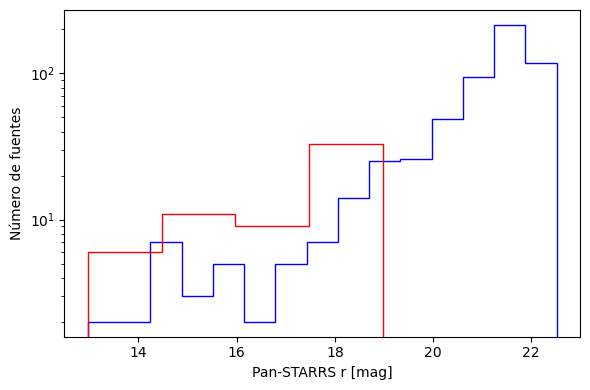

In [22]:
plt.figure(figsize=(6, 4))
plt.hist(ps1_sources["rmag"], bins="scott", histtype="step", color='b')
plt.hist(ps1_bright["rmag"], bins="scott", histtype="step", color='r')
plt.xlabel("Pan-STARRS r [mag]")
plt.ylabel("Número de fuentes")
plt.yscale("log")
plt.tight_layout()

# Gaia

El módulo `astroquery.gaia` proporciona acceso al archivo de Gaia mediante el protocolo TAP.

Podemos realizar:

- Búsquedas circulares.

- Consultas ADQL personalizadas.

- Consultas síncronas y asíncronas.

- Cruces entre tablas.

- Descarga de resultados.

- Exploración de las tablas disponibles.

La tabla principal de Gaia DR3 es:

```text

gaiadr3.gaia_source

El archivo de Gaia puede consultarse mediante búsquedas cónicas o mediante ADQL, el lenguaje utilizado por servicios TAP para realizar consultas astronómicas estructuradas. 

In [23]:
Gaia.ROW_LIMIT = -1

`Gaia.ROW_LIMIT = -1` elimina el límite de filas impuesto por la interfaz de Astroquery.

Debe utilizarse con cuidado para regiones muy grandes o consultas que seleccionen muchas columnas.

In [24]:
gaia_columns = [
    "source_id",
    "designation",
    "ra",
    "ra_error",
    "dec",
    "dec_error",
    "ref_epoch",
    "parallax",
    "parallax_error",
    "pmra",
    "pmra_error",
    "pmdec",
    "pmdec_error",
    "phot_g_mean_mag",
    "phot_bp_mean_mag",
    "phot_rp_mean_mag",
    "phot_g_mean_flux_over_error",
    "ruwe",
    "duplicated_source",
    "phot_variable_flag",
    "classprob_dsc_combmod_star",
]

In [25]:
job_gaia = Gaia.cone_search_async(coordinate=coord, radius=radius, table_name="gaiadr3.gaia_source", columns=gaia_columns,)

INFO: Query finished. [astroquery.utils.tap.core]


In [26]:
type(job_gaia)

astroquery.utils.tap.model.job.Job

In [27]:
gaia_sources = job_gaia.get_results()
gaia_sources

SOURCE_ID,DESIGNATION,ra,ra_error,dec,dec_error,ref_epoch,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,phot_g_mean_flux_over_error,ruwe,duplicated_source,phot_variable_flag,classprob_dsc_combmod_star,dist
,,deg,mas,deg,mas,yr,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,mag,mag,mag,,,,,,
int64,object,float64,float32,float64,float32,float64,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,bool,object,float32,float64
3687328383958193792,Gaia DR3 3687328383958193792,198.21376953379493,0.34882265,-1.011808915441583,0.23332773,2016.0,1.0266191388282089,0.42453536,-7.47893061385133,0.52580625,-4.17469363803018,0.37020007,19.623413,20.830137,18.48261,289.35477,1.0251358,False,NOT_AVAILABLE,0.99998426,0.014527664858485306
3687328448383572096,Gaia DR3 3687328448383572096,198.20641010448392,1.0445523,-1.012550681313811,0.8671387,2016.0,-1.0772709391191866,1.4176993,-19.01429144741534,1.5483861,-9.913179313344202,1.6653322,20.681274,20.700804,19.380686,104.13297,1.2220016,False,NOT_AVAILABLE,0.9996945,0.02082966301184847
3687328379662981632,Gaia DR3 3687328379662981632,198.21105704065926,0.2622837,-1.0201600787864602,0.1690154,2016.0,0.37790959582055433,0.3173182,-15.674779375567624,0.3993009,-7.0087935282037,0.26080188,19.139652,19.84314,18.286999,374.36163,0.9545144,False,NOT_AVAILABLE,0.999994,0.02267068077262537
3687328448385824768,Gaia DR3 3687328448385824768,198.20126591228578,0.9360443,-1.0077035585056087,0.7760215,2016.0,0.5138046405254113,1.1867138,-10.91494635762298,1.6592649,-11.794838156192531,1.7431574,20.52204,21.270731,19.594976,130.28992,1.0261981,False,NOT_AVAILABLE,0.99999744,0.02368576356298206
3687328448382459264,Gaia DR3 3687328448382459264,198.20196690177508,0.27156094,-1.0140625836317605,0.19061947,2016.0,0.49732712049690514,0.33000657,-2.4634795148963633,0.4255292,-14.277315636077374,0.29852292,19.098255,19.5257,18.585651,361.889,1.1874684,False,NOT_AVAILABLE,0.9999367,0.025428453438123257
3687327520669521152,Gaia DR3 3687327520669521152,198.21844724120365,0.106061086,-1.0299223077361848,0.074819885,2016.0,2.017153471967813,0.12873688,12.178018563937126,0.17361781,-8.104697964599655,0.11966163,17.722343,18.825571,16.677488,844.52014,0.99075687,False,NOT_AVAILABLE,0.99979013,0.028829131094185396
3687327589388998912,Gaia DR3 3687327589388998912,198.24708079844652,1.0738221,-1.020909065489553,0.69889635,2016.0,-0.7095893479318827,1.4840021,-0.07450429037168277,1.8031007,-1.0335159097754525,1.6887801,20.74961,21.358103,20.156073,100.140564,1.0082735,False,NOT_AVAILABLE,0.81069106,0.029913904638765317
3687327520669520896,Gaia DR3 3687327520669520896,198.21600651356906,0.46573427,-1.032715937928314,0.30914518,2016.0,1.468758107565654,0.59494424,-79.52893240873797,0.79941076,13.034635091578693,0.5234341,19.906647,20.654444,19.007914,226.05313,0.96904814,False,NOT_AVAILABLE,0.99998945,0.03210433241695731


In [28]:
print(f"Número de fuentes de Gaia DR3: {len(gaia_sources)}")

Número de fuentes de Gaia DR3: 134


In [29]:
gaia_sources[["SOURCE_ID", "ra", "dec", "phot_g_mean_mag", "parallax", "ruwe",]][:10]

SOURCE_ID,ra,dec,phot_g_mean_mag,parallax,ruwe
,deg,deg,mag,mas,
int64,float64,float64,float32,float64,float32
3687328383958193792,198.21376953379493,-1.011808915441583,19.623413,1.0266191388282089,1.0251358
3687328448383572096,198.20641010448392,-1.012550681313811,20.681274,-1.0772709391191866,1.2220016
3687328379662981632,198.21105704065926,-1.0201600787864602,19.139652,0.37790959582055433,0.9545144
3687328448385824768,198.20126591228578,-1.0077035585056087,20.52204,0.5138046405254113,1.0261981
3687328448382459264,198.20196690177508,-1.0140625836317605,19.098255,0.49732712049690514,1.1874684
3687327520669521152,198.21844724120365,-1.0299223077361848,17.722343,2.017153471967813,0.99075687
3687327589388998912,198.24708079844652,-1.020909065489553,20.74961,-0.7095893479318827,1.0082735
3687327520669520896,198.21600651356906,-1.032715937928314,19.906647,1.468758107565654,0.96904814


# Consultas ADQL

ADQL, Astronomical Data Query Language, tiene una sintaxis similar a SQL, pero incorpora funciones para trabajar con coordenadas y regiones del cielo.

Una consulta básica contiene:

- `SELECT`: columnas que queremos obtener.

- `FROM`: tabla que queremos consultar.

- `WHERE`: condiciones que deben cumplir las fuentes.

- `ORDER BY`: orden de los resultados.

La función `CONTAINS` permite seleccionar fuentes dentro de una región circular.

In [30]:
ra_deg = coord.ra.deg
dec_deg = coord.dec.deg
radius_deg = radius.to_value(u.deg)

ra_deg, dec_deg, radius_deg

(198.22416666666663, -1.0016666666666667, 0.1)

In [31]:
query_gaia = f"""
SELECT
    source_id,
    designation,
    ra,
    dec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,

    DISTANCE(
        POINT('ICRS', ra, dec),
        POINT('ICRS', {ra_deg}, {dec_deg})
    ) AS distance_deg

FROM gaiadr3.gaia_source

WHERE 1 = CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE(
        'ICRS',
        {ra_deg},
        {dec_deg},
        {radius_deg}
    )
)

ORDER BY distance_deg

"""

In [32]:
print(query_gaia)


SELECT
    source_id,
    designation,
    ra,
    dec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,

    DISTANCE(
        POINT('ICRS', ra, dec),
        POINT('ICRS', 198.22416666666663, -1.0016666666666667)
    ) AS distance_deg

FROM gaiadr3.gaia_source

WHERE 1 = CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE(
        'ICRS',
        198.22416666666663,
        -1.0016666666666667,
        0.1
    )
)

ORDER BY distance_deg




In [33]:
job_gaia_adql = Gaia.launch_job_async(query_gaia)
gaia_adql = job_gaia_adql.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [34]:
gaia_adql

SOURCE_ID,DESIGNATION,ra,dec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,distance_deg
,,deg,deg,mag,mag,mag,
int64,object,float64,float64,float32,float32,float32,float64
3687328383958193792,Gaia DR3 3687328383958193792,198.21376953379493,-1.011808915441583,19.623413,20.830137,18.48261,0.014523505459216258
3687328448383572096,Gaia DR3 3687328448383572096,198.20641010448392,-1.012550681313811,20.681274,20.700804,19.380686,0.02082450166551394
3687328379662981632,Gaia DR3 3687328379662981632,198.21105704065926,-1.0201600787864602,19.139652,19.84314,18.286999,0.022667489688561426
3687328448385824768,Gaia DR3 3687328448385824768,198.20126591228578,-1.0077035585056087,20.52204,21.270731,19.594976,0.0236796827456392
3687328448382459264,Gaia DR3 3687328448382459264,198.20196690177508,-1.0140625836317605,19.098255,19.5257,18.585651,0.025423135867712325
3687327520669521152,Gaia DR3 3687327520669521152,198.21844724120365,-1.0299223077361848,17.722343,18.825571,16.677488,0.02882850669806331
3687327589388998912,Gaia DR3 3687327589388998912,198.24708079844652,-1.020909065489553,20.74961,21.358103,20.156073,0.029919287874380526
3687327520669520896,Gaia DR3 3687327520669520896,198.21600651356906,-1.032715937928314,19.906647,20.654444,19.007914,0.032103338731771104


Podemos incluir criterios adicionales dentro de `WHERE`.

En el siguiente ejemplo seleccionaremos fuentes:

- Con probabilidad estelar superior a 0.9.

- No marcadas como variables.

- Con una medición válida de magnitud \(G\).

In [35]:
query_gaia_stars = f"""
SELECT
    source_id,
    ra,
    dec,
    parallax,
    pmra,
    pmdec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    phot_variable_flag,
    classprob_dsc_combmod_star,

    DISTANCE(
        POINT('ICRS', ra, dec),
        POINT('ICRS', {ra_deg}, {dec_deg})
    ) AS distance_deg

FROM gaiadr3.gaia_source

WHERE 1 = CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE(
        'ICRS',
        {ra_deg},
        {dec_deg},
        {radius_deg}
    )
)

AND classprob_dsc_combmod_star > 0.9
AND phot_g_mean_mag IS NOT NULL
AND phot_variable_flag <> 'VARIABLE'

ORDER BY distance_deg

"""

In [36]:
job_gaia_stars = Gaia.launch_job_async(query_gaia_stars)
gaia_stars = job_gaia_stars.get_results()
print(f"Número de estrellas seleccionadas: {len(gaia_stars)}")

INFO: Query finished. [astroquery.utils.tap.core]
Número de estrellas seleccionadas: 123


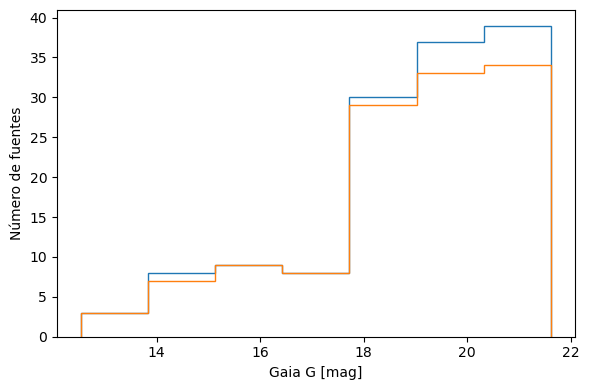

In [37]:
plt.figure(figsize=(6, 4))
plt.hist(
    gaia_adql["phot_g_mean_mag"],
    bins="scott",
    histtype="step",
)
plt.hist(
    gaia_stars["phot_g_mean_mag"],
    bins="scott",
    histtype="step",
)
plt.xlabel("Gaia G [mag]")
plt.ylabel("Número de fuentes")
plt.tight_layout()

In [38]:
valid_cmd = (
    np.isfinite(gaia_stars["phot_bp_mean_mag"])
    & np.isfinite(gaia_stars["phot_rp_mean_mag"])
    & np.isfinite(gaia_stars["phot_g_mean_mag"])
)

bp_rp = (
    gaia_stars["phot_bp_mean_mag"][valid_cmd]
    - gaia_stars["phot_rp_mean_mag"][valid_cmd]
)

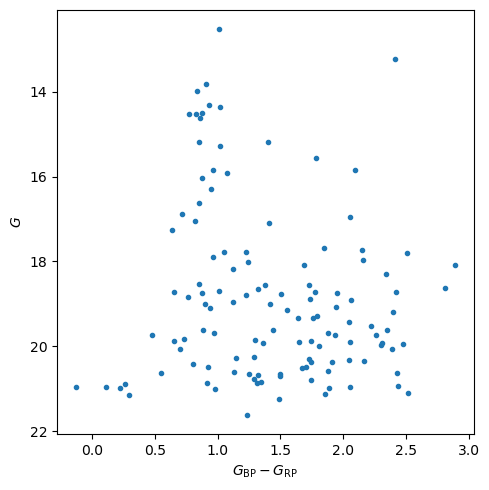

In [39]:
plt.figure(figsize=(5, 5))

plt.scatter(
    bp_rp,
    gaia_stars["phot_g_mean_mag"][valid_cmd],
    marker=".",
)

plt.gca().invert_yaxis()
plt.xlabel(r"$G_{\rm BP}-G_{\rm RP}$")
plt.ylabel(r"$G$")
plt.tight_layout()

El archivo de Gaia contiene numerosas tablas adicionales.

Podemos solicitar sus nombres y buscar aquellas relacionadas con un tema particular.

In [40]:
gaia_tables = Gaia.load_tables(only_names=True)
len(gaia_tables)

INFO: Retrieving tables... [astroquery.utils.tap.core]


INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]


248

In [41]:
for table in gaia_tables:
    name = table.get_qualified_name()
    print(name)

external.external.apassdr9
external.external.catwise2020
external.external.gaiadr2_astrophysical_parameters
external.external.gaiadr2_geometric_distance
external.external.gaiaedr3_distance
external.external.gaiaedr3_gcns_main_1
external.external.gaiaedr3_gcns_rejected_1
external.external.gaiaedr3_spurious
external.external.gaia_eso_survey
external.external.galex_ais
external.external.lamost_dr9_lrs
external.external.lamost_dr9_mrs
external.external.ravedr5_com
external.external.ravedr5_dr5
external.external.ravedr5_gra
external.external.ravedr5_on
external.external.ravedr6
external.external.sdssdr13_photoprimary
external.external.skymapperdr1_master
external.external.skymapperdr2_master
external.external.tmass_xsc
external.external.xgboost_table1
external.external.xgboost_table2
gaiadr1.gaiadr1.aux_qso_icrf2_match
gaiadr1.gaiadr1.ext_phot_zero_point
gaiadr1.gaiadr1.allwise_best_neighbour
gaiadr1.gaiadr1.allwise_neighbourhood
gaiadr1.gaiadr1.gsc23_best_neighbour
gaiadr1.gaiadr1.gsc23_ne

In [42]:
galaxy_table = Gaia.load_table("gaiadr3.galaxy_candidates")
len(galaxy_table.columns)

Retrieving table 'gaiadr3.galaxy_candidates'


38

In [43]:
for column in galaxy_table.columns:
    print(column.name)

solution_id
source_id
vari_best_class_name
vari_best_class_score
classprob_dsc_combmod_galaxy
classprob_dsc_combmod_quasar
classlabel_dsc
classlabel_dsc_joint
classlabel_oa
redshift_ugc
redshift_ugc_lower
redshift_ugc_upper
n_transits
posangle_sersic
posangle_sersic_error
intensity_sersic
intensity_sersic_error
radius_sersic
radius_sersic_error
ellipticity_sersic
ellipticity_sersic_error
n_sersic
n_sersic_error
l2_sersic
morph_params_corr_vec_sersic
flags_sersic
posangle_de_vaucouleurs
posangle_de_vaucouleurs_error
intensity_de_vaucouleurs
intensity_de_vaucouleurs_error
radius_de_vaucouleurs
radius_de_vaucouleurs_error
ellipticity_de_vaucouleurs
ellipticity_de_vaucouleurs_error
l2_de_vaucouleurs
morph_params_corr_vec_de_vaucouleurs
flags_de_vaucouleurs
source_selection_flags


# MAST

MAST, Mikulski Archive for Space Telescopes, contiene observaciones de misiones como:

- Hubble.

- TESS.

- Kepler y K2.

- GALEX.

- JWST.

- FUSE.

- IUE.

Podemos utilizar `Observations` para buscar observaciones alrededor de una coordenada.

El módulo astroquery.mast proporciona interfaces para buscar observaciones, filtrar resultados, examinar productos asociados y descargar archivos

In [44]:
observations = Observations.query_region(coord, radius=1 * u.arcmin,)
observations

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,wave_min,wave_max,distance
str7,str5,str19,str11,str4,str9,str16,str16,str5,str31,float64,float64,str5,str18,int64,float64,float64,float64,str16,float64,float64,str64,float64,str3,str3,int64,str202,str130,str124,str6,bool,float64,str9,float64,float64,float64
science,TESS,SPOC,Photometer,TESS,TESS,Optical,TESS FFI,--,tess-s0023-1-4,201.72459294778727,3.6934751722529096,image,"Ricker, George",3,58927.60900168,58954.38016507,1425.599383,Optical,600.0,1000.0,--,58973.0,N/A,--,23,POLYGON 193.81953900 0.54397900 198.49363700 11.51198300 209.78722200 6.49426400 204.79244700 -3.85673400 193.81953900 0.54397900,--,--,PUBLIC,False,nan,27386990,600.0,1000.0,0.0
science,TESS,SPOC,Photometer,TESS,TESS,Optical,TESS FFI,--,tess-s0046-4-4,198.94336432898132,-0.834037155387192,image,"Ricker, George",3,59551.058376493056,59578.19973341435,475.199787,Optical,600.0,1000.0,--,59603.0,N/A,--,46,POLYGON 202.180771 -8.694088 191.145267 -4.081585 195.995887 7.140858 206.450089 2.316856 202.180771 -8.694088,--,--,PUBLIC,False,nan,71644391,600.0,1000.0,0.0
science,TESS,SPOC,Photometer,TESS,TESS,Optical,TESS FFI,--,tess-s0050-1-3,196.42365980117674,5.870737443831625,image,"Ricker, George",3,59664.77567635417,59691.011557847225,475.199783,Optical,600.0,1000.0,--,59710.0,N/A,--,50,POLYGON 188.917184 2.653824 192.667108 13.527176 204.294673 9.105543 199.806861 -1.932031 188.917184 2.653824,--,--,PUBLIC,False,nan,83315698,600.0,1000.0,0.0
science,TESS,SPOC,Photometer,TESS,TESS,Optical,TESS FFI,--,tess-s0091-1-2,200.31768625116092,-1.335677039305719,image,"Ricker, George",3,60774.79012172454,60802.26173586806,158.399927,Optical,600.0,1000.0,--,60808.0,N/A,--,91,POLYGON 203.719652 -9.134348 192.573442 -4.731965 197.212296 6.582566 207.763944 1.969674 203.719652 -9.134348,--,--,PUBLIC,False,nan,262964746,600.0,1000.0,0.0
science,SDSS,SDSS Legacy Imaging,SDSS Camera,SDSS,u;g;r;i;z,OPTICAL,000745-1-0264,FIELD,sdss_image_000745-1-0264,198.287340626,-0.950417410127,image,SDSS Collaboration,3,51257.35059988426,51257.35453931685,53.886976,OPTICAL,304.79999999999995,1083.3000000000002,Sloan Digital Sky Survey (SDSS) Legacy Imaging Data,55571.0,N/A,--,--,POLYGON 198.20557291477564 -1.0630018994458228 198.20550945939382 -0.8379370711425089 198.36910304266672 -0.8379409339505096 198.36917715903567 -1.0630057589960333 198.20557291477564 -1.0630018994458228,mast:SDSS/sdss/imaging/745/1/264/frame-irg-000745-1-0264.jpg,mast:SDSS/sdss/imaging/745/1/264/photoObj-000745-1-0264.fits,PUBLIC,False,nan,295724488,304.79999999999995,1083.3000000000002,0.0
science,SDSS,SDSS Legacy Imaging,SDSS Camera,SDSS,u;g;r;i;z,OPTICAL,000756-1-0550,FIELD,sdss_image_000756-1-0550,198.166563639,-0.944064761359,image,SDSS Collaboration,3,51259.34485300926,51259.34879446241,53.911552,OPTICAL,304.79999999999995,1083.3000000000002,Sloan Digital Sky Survey (SDSS) Legacy Imaging Data,55571.0,N/A,--,--,POLYGON 198.0847467003895 -1.0566459642237702 198.08472471110886 -0.8316089331445488 198.24837529536703 -0.8315915686721215 198.24840787674208 -1.0566285984674042 198.0847467003895 -1.0566459642237702,mast:SDSS/sdss/imaging/756/1/550/frame-irg-000756-1-0550.jpg,mast:SDSS/sdss/imaging/756/1/550/photoObj-000756-1-0550.fits,PUBLIC,False,nan,297981727,304.79999999999995,1083.3000000000002,0.0
science,SDSS,SDSS Legacy Imaging,SDSS Camera,SDSS,u;g;r;i;z,OPTICAL,001334-1-0011,FIELD,sdss_image_001334-1-0011,198.297590991,-0.944744930674,image,SDSS Collaboration,3,51638.33251689815,51638.336457840924,53.907456,OPTICAL,304.79999999999995,1083.3000000000002,Sloan Digital Sky Survey (SDSS) Legacy Imaging Data,55571.0,N/A,--,--,POLYGON 198.21572081859193 -1.05735640470645

In [45]:
print(f"Número de observaciones encontradas: {len(observations)}")

Número de observaciones encontradas: 22


In [46]:
observations.colnames

['intentType',
 'obs_collection',
 'provenance_name',
 'instrument_name',
 'project',
 'filters',
 'wave_region',
 'target_name',
 'target_classification',
 'obs_id',
 's_ra',
 's_dec',
 'dataproduct_type',
 'proposal_pi',
 'calib_level',
 't_min',
 't_max',
 't_exptime',
 'wavelength_region',
 'em_min',
 'em_max',
 'obs_title',
 't_obs_release',
 'proposal_id',
 'proposal_type',
 'sequence_number',
 's_region',
 'jpegURL',
 'dataURL',
 'dataRights',
 'mtFlag',
 'srcDen',
 'obsid',
 'wave_min',
 'wave_max',
 'distance']

In [47]:
columns_to_show = [
    "obs_collection",
    "instrument_name",
    "filters",
    "target_name",
    "t_exptime",
]

available_columns = [
    column
    for column in columns_to_show
    if column in observations.colnames
]
observations[available_columns][:10]

obs_collection,instrument_name,filters,target_name,t_exptime
str5,str11,str9,str16,float64
TESS,Photometer,TESS,TESS FFI,1425.599383
TESS,Photometer,TESS,TESS FFI,475.199787
TESS,Photometer,TESS,TESS FFI,475.199783
TESS,Photometer,TESS,TESS FFI,158.399927
SDSS,SDSS Camera,u;g;r;i;z,000745-1-0264,53.886976
SDSS,SDSS Camera,u;g;r;i;z,000756-1-0550,53.911552
SDSS,SDSS Camera,u;g;r;i;z,001334-1-0011,53.907456
SDSS,SDSS Camera,u;g;r;i;z,001451-1-0021,53.907456
SDSS,SDSS Camera,u;g;r;i;z,000745-1-0263,53.886976


Podemos resumir cuántas observaciones provienen de cada misión o colección.

In [48]:
if len(observations) > 0:
    collections, counts = np.unique(
        observations["obs_collection"],
        return_counts=True,
    )
    for collection, count in zip(collections, counts):
        print(f"{collection}: {count}")

GALEX: 4
HLSP: 3
PS1: 5
SDSS: 6
TESS: 4


Para descargar datos, primero debemos obtener la lista de productos asociados con una observación.

En este tutorial solamente exploraremos los metadatos y no descargaremos archivos automáticamente, ya que algunos productos pueden ser grandes.

In [49]:
first_observation = observations[:1]
products = Observations.get_product_list(first_observation)

In [50]:
products

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str8,str4,str5,str34,str29,str1,str62,str7,str1,str4,str1,str4,str20,str3,str44,int64,str8,str6,int64,str4
27349813,TESS,image,tess2020084105920-s0023-1-4-0177-s,Calibrated full frame image,S,mast:TESS/product/tess2020084105920-s0023-1-4-0177-s_ffic.fits,SCIENCE,--,FFIC,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020084105920-s0023-1-4-0177-s_ffic.fits,35547840,27386990,PUBLIC,2,TESS
27349813,TESS,image,tess2020084105920-s0023-1-4-0177-s,Uncalibrated full frame image,S,mast:TESS/product/tess2020084105920-s0023-1-4-0177-s_ffir.fits,SCIENCE,--,FFIR,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020084105920-s0023-1-4-0177-s_ffir.fits,17775360,27386990,PUBLIC,1,TESS
27349814,TESS,image,tess2020098195920-s0023-1-4-0177-s,Calibrated full frame image,S,mast:TESS/product/tess2020098195920-s0023-1-4-0177-s_ffic.fits,SCIENCE,--,FFIC,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020098195920-s0023-1-4-0177-s_ffic.fits,35547840,27386990,PUBLIC,2,TESS
27349814,TESS,image,tess2020098195920-s0023-1-4-0177-s,Uncalibrated full frame image,S,mast:TESS/product/tess2020098195920-s0023-1-4-0177-s_ffir.fits,SCIENCE,--,FFIR,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020098195920-s0023-1-4-0177-s_ffir.fits,17775360,27386990,PUBLIC,1,TESS
27349816,TESS,image,tess2020082022920-s0023-1-4-0177-s,Calibrated full frame image,S,mast:TESS/product/tess2020082022920-s0023-1-4-0177-s_ffic.fits,SCIENCE,--,FFIC,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020082022920-s0023-1-4-0177-s_ffic.fits,35547840,27386990,PUBLIC,2,TESS
27349816,TESS,image,tess2020082022920-s0023-1-4-0177-s,Uncalibrated full frame image,S,mast:TESS/product/tess2020082022920-s0023-1-4-0177-s_ffir.fits,SCIENCE,--,FFIR,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020082022920-s0023-1-4-0177-s_ffir.fits,17775360,27386990,PUBLIC,1,TESS
27349832,TESS,image,tess2020089105920-s0023-1-4-0177-s,Calibrated full frame image,S,mast:TESS/product/tess2020089105920-s0023-1-4-0177-s_ffic.fits,SCIENCE,--,FFIC,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020089105920-s0023-1-4-0177-s_ffic.fits,35547840,27386990,PUBLIC,2,TESS
27349832,TESS,image,tess2020089105920-s0023-1-4-0177-s,Uncalibrated full frame image,S,mast:TESS/product/tess2020089105920-s0023-1-4-0177-s_ffir.fits,SCIENCE,--,FFIR,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020089105920-s0023-1-4-0177-s_ffir.fits,17775360,27386990,PUBLIC,1,TESS
27366872,TESS,image,tess2020094012920-s0023-1-4-0177-s,Calibrated full frame image,S,mast:TESS/product/tess2020094012920-s0023-1-4-0177-s_ffic.fits,SCIENCE,--,FFIC,--,SPOC,spoc-4.0.30-20200415,N/A,tess2020094012920-s0023-1-4-0177-s_ffic.fits,35536320,27386990,PUBLIC,2,TESS


In [51]:
print(f"Número de productos: {len(products)}")
print(products.colnames)

Número de productos: 2476
['obsID', 'obs_collection', 'dataproduct_type', 'obs_id', 'description', 'type', 'dataURI', 'productType', 'productGroupDescription', 'productSubGroupDescription', 'productDocumentationURL', 'project', 'prvversion', 'proposal_id', 'productFilename', 'size', 'parent_obsid', 'dataRights', 'calib_level', 'filters']


# JPL Horizons

JPL Horizons proporciona efemérides y elementos orbitales para:

- Planetas.

- Satélites naturales.

- Asteroides.

- Cometas.

- Algunas naves espaciales.

Para realizar una consulta debemos especificar:

- El identificador del objeto.

- La ubicación del observador.

- El intervalo de tiempo.

Como ejemplo consultaremos el asteroide Polymele.

El código del observatorio `500` representa el geocentro.

In [52]:
polymele = Horizons(
    id="15094",
    location="500",
    epochs={
        "start": "2026-06-01",
        "stop": "2026-06-03",
        "step": "6h",
    },
)

In [53]:
ephemerides = polymele.ephemerides()
ephemerides

targetname,datetime_str,datetime_jd,H,G,solar_presence,flags,RA,DEC,RA_app,DEC_app,RA_rate,DEC_rate,AZ,EL,AZ_rate,EL_rate,sat_X,sat_Y,sat_PANG,siderealtime,airmass,magextinct,V,surfbright,illumination,illum_defect,sat_sep,sat_vis,ang_width,PDObsLon,PDObsLat,PDSunLon,PDSunLat,SubSol_ang,SubSol_dist,NPole_ang,NPole_dist,EclLon,EclLat,r,r_rate,delta,delta_rate,lighttime,vel_sun,vel_obs,elong,elongFlag,alpha,lunar_elong,lunar_illum,sat_alpha,sunTargetPA,velocityPA,OrbPlaneAng,constellation,TDB-UT,ObsEclLon,ObsEclLat,NPole_RA,NPole_DEC,GlxLon,GlxLat,solartime,earth_lighttime,RA_3sigma,DEC_3sigma,SMAA_3sigma,SMIA_3sigma,Theta_3sigma,Area_3sigma,RSS_3sigma,r_3sigma,r_rate_3sigma,SBand_3sigma,XBand_3sigma,DoppDelay_3sigma,true_anom,hour_angle,alpha_true,PABLon,PABLat
---,---,d,mag,---,---,---,deg,deg,deg,deg,arcsec / h,arcsec / h,deg,deg,arcsec / min,arcsec / min,arcsec,arcsec,deg,---,---,mag,mag,mag / arcsec2,%,arcsec,arcsec,---,arcsec,deg,deg,deg,deg,deg,arcsec,deg,arcsec,deg,deg,AU,km / s,AU,km / s,min,km / s,km / s,deg,---,deg,deg,%,deg,deg,deg,deg,---,s,deg,deg,deg,deg,deg,deg,---,min,arcsec,arcsec,arcsec,arcsec,deg,arcsec2,arcsec,km,km / s,Hz,Hz,s,deg,---,deg,deg,deg
str25,str17,float64,float64,float64,str1,str1,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,str1,float64,int64,int64,int64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,float64,float64,float64,float64,float64,float64,str3,float64,float64,float64,int64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64
15094 Polymele (1999 WB2),2026-Jun-01 00:00,2461192.5,11.77,0.22,,,198.28073,-0.98382,198.62497,-1.12551,-7.51783,-2.15102,--,--,--,--,432804.011,-83345.51,73.957,--,999,--,19.507,8.088,99.47286,3.1e-05,456540.9,*,0.005886,--,--,--,--,296.99,0.0,--,--,205.5781,5.5115,5.603576946065,0.6524031,4.93701386546031,22.0360355,41.05989228,12.0725602,23.3679033,126.8169,/T,8.3238,60.8,99.4595,45.2246,117.034,303.259,0.90214,Vir,69.184898,197.6126388,6.2568653,--,--,314.322614,61.40627,--,0.0,0.03,0.02,0.036,0.00097,-33.215,0.0001098,0.036,27.8657,1.8e-06,0.04,0.15,0.000186,148.8144,--,8.3272,201.4098,5.9003
15094 Polymele (1999 WB2),2026-Jun-01 06:00,2461192.75,11.77,0.22,,,198.26828,-0.98743,198.61252,-1.12913,-7.41971,-2.19316,--,--,--,--,431804.732,-83481.12,74.088,--,999,--,19.509,8.089,99.46942,3.1e-05,455652.4,*,0.005882,--,--,--,--,296.95,0.0,--,--,205.5956,5.5079,5.603671113345,0.6520657,4.94020078869123,22.1078881,41.08639711,12.0723425,23.4102241,126.5701,/T,8.351,63.7,99.1237,45.4443,116.987,303.26,0.91198,Vir,69.184893,197.6024316,6.2487968,--,--,314.295647,61.404914,--,0.0,0.03,0.02,0.036,0.00097,-33.217,0.0001096,0.036,27.9205,1.8e-06,0.04,0.15,0.000186,148.8321,--,8.3543,201.4134,5.8946
15094 Polymele (1999 WB2),2026-Jun-01 12:00,2461193.0,11.77,0.22,,,198.25599,-0.99111,198.60024,-1.13282,-7.32144,-2.23528,--,--,--,--,430807.151,-83615.54,74.219,--,999,--,19.512,8.09,99.466,3.1e-05,454764.5,*,0.005878,--,--,--,--,296.9,0.0,--,--,205.6131,5.5042,5.603765231883,0.6517282,4.94339805463471,22.1792979,41.11298796,12.072125,23.4526432,126.3235,/T,8.378,66.6,98.6781,45.664,116.94,303.261,0.92178,Vir,69.184887,197.592404,6.2407251,--,--,314.268994,61.403454,--,0.0,0.03,0.02,0.036,0.00097,-33.22,0.0001095,0.036,27.9749,1.8e-06,0.04,0.15,0.000187,148.8499,--,8.3813,201.4171,5.8888
15094 Polymele (1999 WB2),2026-Jun-01 18:00,2461193.25,11.77,0.22,,,198.24386,-0.99486,198.58811,-1.13657,-7.22304,-2.27738,--,--,--,--,429811.273,-83748.77,74.35,--,999,--,19.514,8.091,99.46258,3.2e-05,453877.2,*,0.005874,--,--,--,--,296.85,0.0,--,--,205.6306,5.5006,5.603859301671,0.6513907,4.94660559939241,22.2502653,41.1396643,12.0719076,23.4951599,126.077,/T,8.4048,69.5,98.1235,45.8837,116

In [54]:
ephemerides.colnames

['targetname',
 'datetime_str',
 'datetime_jd',
 'H',
 'G',
 'solar_presence',
 'flags',
 'RA',
 'DEC',
 'RA_app',
 'DEC_app',
 'RA_rate',
 'DEC_rate',
 'AZ',
 'EL',
 'AZ_rate',
 'EL_rate',
 'sat_X',
 'sat_Y',
 'sat_PANG',
 'siderealtime',
 'airmass',
 'magextinct',
 'V',
 'surfbright',
 'illumination',
 'illum_defect',
 'sat_sep',
 'sat_vis',
 'ang_width',
 'PDObsLon',
 'PDObsLat',
 'PDSunLon',
 'PDSunLat',
 'SubSol_ang',
 'SubSol_dist',
 'NPole_ang',
 'NPole_dist',
 'EclLon',
 'EclLat',
 'r',
 'r_rate',
 'delta',
 'delta_rate',
 'lighttime',
 'vel_sun',
 'vel_obs',
 'elong',
 'elongFlag',
 'alpha',
 'lunar_elong',
 'lunar_illum',
 'sat_alpha',
 'sunTargetPA',
 'velocityPA',
 'OrbPlaneAng',
 'constellation',
 'TDB-UT',
 'ObsEclLon',
 'ObsEclLat',
 'NPole_RA',
 'NPole_DEC',
 'GlxLon',
 'GlxLat',
 'solartime',
 'earth_lighttime',
 'RA_3sigma',
 'DEC_3sigma',
 'SMAA_3sigma',
 'SMIA_3sigma',
 'Theta_3sigma',
 'Area_3sigma',
 'RSS_3sigma',
 'r_3sigma',
 'r_rate_3sigma',
 'SBand_3sigma',
 '

In [55]:
columns_ephemerides = [
    "datetime_str",
    "RA",
    "DEC",
    "RA_rate",
    "DEC_rate",
    "r",
    "delta",
    "V",
]

available_columns = [
    column
    for column in columns_ephemerides
    if column in ephemerides.colnames
]
ephemerides[available_columns]

datetime_str,RA,DEC,RA_rate,DEC_rate,r,delta,V
---,deg,deg,arcsec / h,arcsec / h,AU,AU,mag
str17,float64,float64,float64,float64,float64,float64,float64
2026-Jun-01 00:00,198.28073,-0.98382,-7.51783,-2.15102,5.603576946065,4.93701386546031,19.507
2026-Jun-01 06:00,198.26828,-0.98743,-7.41971,-2.19316,5.603671113345,4.94020078869123,19.509
2026-Jun-01 12:00,198.25599,-0.99111,-7.32144,-2.23528,5.603765231883,4.94339805463471,19.512
2026-Jun-01 18:00,198.24386,-0.99486,-7.22304,-2.27738,5.603859301671,4.94660559939241,19.514
2026-Jun-02 00:00,198.2319,-0.99868,-7.1245,-2.31945,5.603953322703,4.94982335909816,19.517
2026-Jun-02 06:00,198.22011,-1.00257,-7.02583,-2.3615,5.60404729497,4.95305126991191,19.519
2026-Jun-02 12:00,198.20848,-1.00653,-6.92703,-2.40352,5.604141218466,4.95628926801387,19.522
2026-Jun-02 18:00,198.19701,-1.01057,-6.8281,-2.44551,5.604235093183,4.95953728959856,19.524


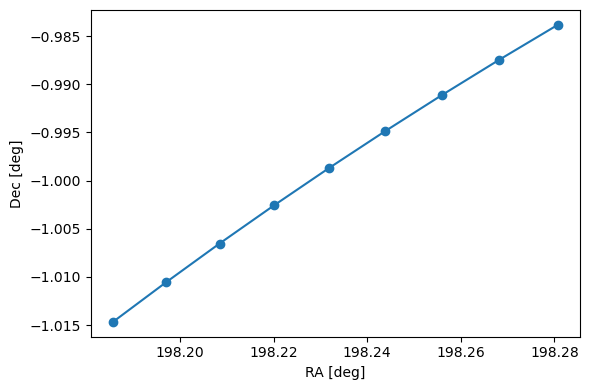

In [56]:
plt.figure(figsize=(6, 4))

plt.plot(
    ephemerides["RA"],
    ephemerides["DEC"],
    marker="o",
)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.tight_layout()

# Conversión a pandas

Las tablas devueltas por Astroquery pueden convertirse a DataFrames de pandas mediante el método:

```python

table.to_pandas()

Esto resulta útil para:

* Filtrar datos.
* Combinar tablas.
* Calcular nuevas columnas.
* Guardar resultados como CSV.

In [57]:
df_gaia = gaia_stars.to_pandas()
type(df_gaia)

pandas.core.frame.DataFrame

In [58]:
df_gaia.head()

,SOURCE_ID,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,phot_variable_flag,classprob_dsc_combmod_star,distance_deg
0,3687328383958193792,198.213770,-1.011809,1.026619,-7.478931,-4.174694,19.623413,20.830137,18.482611,NOT_AVAILABLE,0.999984,0.014524
1,3687328448383572096,198.206410,-1.012551,-1.077271,-19.014291,-9.913179,20.681274,20.700804,19.380686,NOT_AVAILABLE,0.999695,0.020825
2,3687328379662981632,198.211057,-1.020160,0.377910,-15.674779,-7.008794,19.139652,19.843140,18.286999,NOT_AVAILABLE,0.999994,0.022667
3,3687328448385824768,198.201266,-1.007704,0.513805,-10.914946,-11.794838,20.522039,21.270731,19.594976,NOT_AVAILABLE,0.999997,0.023680
4,3687328448382459264,198.201967,-1.014063,0.497327,-2.463480,-14.277316,19.098255,19.525700,18.585651,NOT_AVAILABLE,0.999937,0.025423


In [59]:
df_gaia.columns

Index(['SOURCE_ID', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
       'phot_variable_flag', 'classprob_dsc_combmod_star', 'distance_deg'],
      dtype='object')

In [60]:
df_gaia.describe()

,SOURCE_ID,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,classprob_dsc_combmod_star,distance_deg
count,1.230000e+02,123.000000,123.000000,105.000000,105.000000,105.000000,123.000000,123.000000,123.000000,123.000000,123.000000
mean,3.687331e+18,198.225029,-1.001383,1.072897,-9.625878,-6.782989,18.800432,19.364817,17.924425,0.999125,0.072214
std,6.090412e+12,0.053378,0.053193,1.972615,16.028393,10.672251,2.057941,2.047798,1.933042,0.003253,0.020521
min,3.687324e+18,198.127754,-1.091055,-1.077271,-85.429641,-55.444362,12.530540,12.951459,11.936441,0.973807,0.014524
25%,3.687327e+18,198.182108,-1.047621,0.367896,-13.213987,-11.790060,17.921652,18.644627,17.088096,0.999696,0.059492
50%,3.687329e+18,198.216648,-1.002057,0.664619,-7.647089,-4.174694,19.335880,20.067434,18.399172,0.999957,0.076551
75%,3.687331e+18,198.276638,-0.951545,1.385584,-2.011096,-0.739413,20.365725,20.798316,19.378218,0.999988,0.089453
max,3.687343e+18,198.320835,-0.908830,18.787793,28.186180,13.034635,21.619286,22.422421,20.833918,0.999999,0.099005


Las columnas con valores enmascarados en una tabla de Astropy normalmente se convierten en valores faltantes de pandas, como `NaN`.

In [61]:
df_gaia.isna().sum().sort_values(ascending=False)

parallax                      18
pmra                          18
pmdec                         18
SOURCE_ID                      0
ra                             0
dec                            0
phot_g_mean_mag                0
phot_bp_mean_mag               0
phot_rp_mean_mag               0
phot_variable_flag             0
classprob_dsc_combmod_star     0
distance_deg                   0
dtype: int64

# Guardar resultados

Las tablas de Astropy pueden guardarse directamente en diferentes formatos.

In [62]:
gaia_stars.write(
    "gaia_sources.ecsv",
    overwrite=True,
)

In [63]:
df_gaia.to_csv(
    "gaia_sources.csv",
    index=False,
)

El formato ECSV conserva mejor la información de unidades y metadatos de Astropy.

CSV es más fácil de abrir en otros programas, pero no conserva automáticamente las unidades físicas.

# Cruce de catálogos por coordenadas

Podemos cruzar las fuentes de Gaia con las fuentes de Pan-STARRS mediante sus coordenadas.

El procedimiento será:

1. Construir un objeto `SkyCoord` para cada catálogo.

2. Encontrar el vecino más cercano.

3. Calcular la separación angular.

4. Conservar solamente asociaciones dentro de una tolerancia máxima.

In [64]:
df_ps1 = ps1_sources.to_pandas()
df_ps1

,objID,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,ymag,e_ymag
0,106691982269760742,198.226972,-1.091346,0.0780,0.0780,NaN,NaN,NaN,NaN,NaN,NaN,20.9602,0.1835,20.5490,0.1385
1,106681982307844774,198.230725,-1.096310,0.0710,0.0710,NaN,NaN,NaN,NaN,21.7138,0.0889,21.4521,0.1840,NaN,NaN
2,106691982362874138,198.236251,-1.088579,0.0042,0.0121,16.4862,0.0025,15.8915,0.0021,15.6739,0.0028,15.5941,0.0030,15.5362,0.0040
3,106691982412241198,198.241138,-1.091047,0.0117,0.0043,20.0777,0.0082,18.8738,0.0098,17.3911,0.0059,16.7229,0.0055,16.3965,0.0073
4,106681982324755304,198.232462,-1.095891,0.0763,0.0539,NaN,NaN,22.0688,0.0822,21.5377,0.0484,21.2303,0.1269,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
718,106881982382903987,198.238188,-0.930397,0.0115,0.0106,20.7008,0.0206,20.4931,0.0159,20.3980,0.0192,20.3321,0.0450,20.1488,0.0308
719,106901982589217629,198.258891,-0.910661,0.0405,0.0360,NaN,NaN,21.7962,0.0472,21.3844,0.0497,21.1632,0.1154,20.1764,0.1797
720,106901982606536950,198.260659,-0.911292,0.0878,0.0878,NaN,NaN,21.8930,0.1930,21.7387,0.0672,NaN,NaN,NaN,NaN
721,106911982225356295,198.222581,-0.903416,0.1008,0.1073,NaN,NaN,22.0776,0.1119,21.5817,0.0994,NaN,NaN,NaN,NaN


In [65]:
coords_gaia = SkyCoord(
    ra=df_gaia["ra"].values * u.deg,
    dec=df_gaia["dec"].values * u.deg,
    frame="icrs",
)

coords_ps1 = SkyCoord(
    ra=df_ps1["RAJ2000"].values * u.deg,
    dec=df_ps1["DEJ2000"].values * u.deg,
    frame="icrs",
)

In [66]:
idx_ps1, separation, _ = (
    coords_gaia.match_to_catalog_sky(coords_ps1)
)

In [67]:
separation.arcsec[:10]

array([0.02357738, 0.06158867, 0.01521064, 0.04959466, 0.02377499,
       0.04295633, 0.28998695, 0.02952259, 0.05603405, 0.02611431])

In [68]:
max_sep = 0.1 * u.arcsec
good_match = separation <= max_sep
print(
    f"Fuentes asociadas: {good_match.sum()} "
    f"de {len(df_gaia)}"
)

Fuentes asociadas: 117 de 123


In [69]:
df_gaia_matched = (
    df_gaia.loc[good_match]
    .reset_index(drop=True)
    .copy()
    .add_prefix("gaia_")
)

df_ps1_matched = (
    df_ps1.iloc[idx_ps1[good_match]]
    .reset_index(drop=True)
    .copy()
    .add_prefix("ps1_")
)

In [70]:
df_gaia_ps1 = pd.concat(
    [
        df_gaia_matched,
        df_ps1_matched,
    ],
    axis=1,
)

df_gaia_ps1["match_sep_arcsec"] = (
    separation[good_match].to_value(u.arcsec)
)

In [71]:
df_gaia_ps1.head()

,gaia_SOURCE_ID,gaia_ra,gaia_dec,gaia_parallax,gaia_pmra,gaia_pmdec,gaia_phot_g_mean_mag,gaia_phot_bp_mean_mag,gaia_phot_rp_mean_mag,gaia_phot_variable_flag,...,ps1_e_gmag,ps1_rmag,ps1_e_rmag,ps1_imag,ps1_e_imag,ps1_zmag,ps1_e_zmag,ps1_ymag,ps1_e_ymag,match_sep_arcsec
0,3687328383958193792,198.213770,-1.011809,1.026619,-7.478931,-4.174694,19.623413,20.830137,18.482611,NOT_AVAILABLE,...,0.0163,20.0854,0.0135,18.9288,0.0101,18.4066,0.0051,18.1319,0.0117,0.023577
1,3687328448383572096,198.206410,-1.012551,-1.077271,-19.014291,-9.913179,20.681274,20.700804,19.380686,NOT_AVAILABLE,...,0.1912,21.3065,0.0402,19.9122,0.0132,19.1891,0.0208,18.8593,0.0155,0.061589
2,3687328379662981632,198.211057,-1.020160,0.377910,-15.674779,-7.008794,19.139652,19.843140,18.286999,NOT_AVAILABLE,...,0.0220,19.1564,0.0125,18.6510,0.0039,18.4513,0.0069,18.3061,0.0120,0.015211
3,3687328448385824768,198.201266,-1.007704,0.513805,-10.914946,-11.794838,20.522039,21.270731,19.594976,NOT_AVAILABLE,...,0.0827,20.6453,0.0333,19.9459,0.0125,19.5943,0.0165,19.4069,0.0391,0.049595
4,3687328448382459264,198.201967,-1.014063,0.497327,-2.463480,-14.277316,19.098255,19.525700,18.585651,NOT_AVAILABLE,...,0.0127,19.0736,0.0118,18.9062,0.0056,18.8355,0.0121,18.7682,0.0241,0.023775


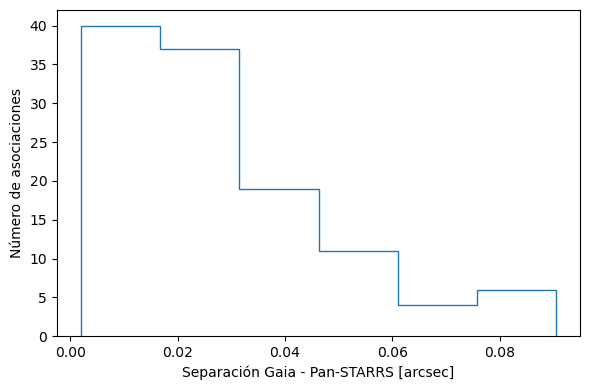

In [72]:
plt.figure(figsize=(6, 4))
plt.hist(
    df_gaia_ps1["match_sep_arcsec"],
    bins="scott",
    histtype="step",
)
plt.xlabel("Separación Gaia - Pan-STARRS [arcsec]")
plt.ylabel("Número de asociaciones")
plt.tight_layout()

# Creación de funciones

Podemos organizar una consulta dentro de una función para utilizarla con diferentes coordenadas y radios.

In [73]:
def query_gaia_region(
    skycoord,
    radius,
    row_limit=-1,
):
    """
    Consulta fuentes de Gaia DR3 alrededor de una coordenada.
    Parameters
    ----------
    skycoord : astropy.coordinates.SkyCoord
        Coordenada central.
    radius : astropy.units.Quantity
        Radio angular de la consulta.
    row_limit : int
        Número máximo de filas. Use -1 para no imponer límite.
    Returns
    -------
    astropy.table.Table
        Fuentes encontradas en Gaia DR3.
    """
    Gaia.ROW_LIMIT = row_limit

    columns = [
        "source_id",
        "ra",
        "ra_error",
        "dec",
        "dec_error",
        "ref_epoch",
        "parallax",
        "parallax_error",
        "pmra",
        "pmra_error",
        "pmdec",
        "pmdec_error",
        "phot_g_mean_mag",
        "phot_bp_mean_mag",
        "phot_rp_mean_mag",
        "ruwe",
        "duplicated_source",
        "phot_variable_flag",
        "classprob_dsc_combmod_star",
    ]

    job = Gaia.cone_search_async(
        coordinate=skycoord,
        radius=radius,
        table_name="gaiadr3.gaia_source",
        columns=columns,
    )

    sources = job.get_results()

    print(
        f"Número de fuentes de Gaia DR3: "
        f"{len(sources)}"
    )

    return sources

In [74]:
gaia_test = query_gaia_region(coord, 3 * u.arcmin,)
gaia_test

INFO: Query finished. [astroquery.utils.tap.core]
Número de fuentes de Gaia DR3: 24


SOURCE_ID,ra,ra_error,dec,dec_error,ref_epoch,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,duplicated_source,phot_variable_flag,classprob_dsc_combmod_star,dist
,deg,mas,deg,mas,yr,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,mag,mag,mag,,,,,
int64,float64,float32,float64,float32,float64,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,bool,object,float32,float64
3687328383958193792,198.21376953379493,0.34882265,-1.011808915441583,0.23332773,2016.0,1.0266191388282089,0.42453536,-7.47893061385133,0.52580625,-4.17469363803018,0.37020007,19.623413,20.830137,18.48261,1.0251358,False,NOT_AVAILABLE,0.99998426,0.014527664858485306
3687328448383572096,198.20641010448392,1.0445523,-1.012550681313811,0.8671387,2016.0,-1.0772709391191866,1.4176993,-19.01429144741534,1.5483861,-9.913179313344202,1.6653322,20.681274,20.700804,19.380686,1.2220016,False,NOT_AVAILABLE,0.9996945,0.02082966301184847
3687328379662981632,198.21105704065926,0.2622837,-1.0201600787864602,0.1690154,2016.0,0.37790959582055433,0.3173182,-15.674779375567624,0.3993009,-7.0087935282037,0.26080188,19.139652,19.84314,18.286999,0.9545144,False,NOT_AVAILABLE,0.999994,0.02267068077262537
3687328448385824768,198.20126591228578,0.9360443,-1.0077035585056087,0.7760215,2016.0,0.5138046405254113,1.1867138,-10.91494635762298,1.6592649,-11.794838156192531,1.7431574,20.52204,21.270731,19.594976,1.0261981,False,NOT_AVAILABLE,0.99999744,0.02368576356298206
3687328448382459264,198.20196690177508,0.27156094,-1.0140625836317605,0.19061947,2016.0,0.49732712049690514,0.33000657,-2.4634795148963633,0.4255292,-14.277315636077374,0.29852292,19.098255,19.5257,18.585651,1.1874684,False,NOT_AVAILABLE,0.9999367,0.025428453438123257
3687327520669521152,198.21844724120365,0.106061086,-1.0299223077361848,0.074819885,2016.0,2.017153471967813,0.12873688,12.178018563937126,0.17361781,-8.104697964599655,0.11966163,17.722343,18.825571,16.677488,0.99075687,False,NOT_AVAILABLE,0.99979013,0.028829131094185396
3687327589388998912,198.24708079844652,1.0738221,-1.020909065489553,0.69889635,2016.0,-0.7095893479318827,1.4840021,-0.07450429037168277,1.8031007,-1.0335159097754525,1.6887801,20.74961,21.358103,20.156073,1.0082735,False,NOT_AVAILABLE,0.81069106,0.029913904638765317
3687327520669520896,198.21600651356906,0.46573427,-1.032715937928314,0.30914518,2016.0,1.468758107565654,0.59494424,-79.52893240873797,0.79941076,13.034635091578693,0.5234341,19.906647,20.654444,19.007914,0.96904814,False,NOT_AVAILABLE,0.99998945,0.03210433241695731


In [75]:
def query_panstarrs_region(
    skycoord,
    radius,
    row_limit=-1,
):
    """
    Consulta Pan-STARRS1 a través de VizieR.
    """
    query = Vizier(
        columns=[
            "objID",
            "RAJ2000",
            "DEJ2000",
            "e_RAJ2000",
            "e_DEJ2000",
            "gmag",
            "e_gmag",
            "rmag",
            "e_rmag",
            "imag",
            "e_imag",
            "zmag",
            "e_zmag",
            "ymag",
            "e_ymag",
        ],
        row_limit=row_limit,
    )

    tables = query.query_region(
        skycoord,
        radius=radius,
        catalog="II/349/ps1",
    )

    sources = tables[0]

    print(
        f"Número de fuentes de Pan-STARRS: "
        f"{len(sources)}"
    )

    return sources

In [76]:
ps1_test = query_panstarrs_region(coord, 3 * u.arcmin,)
ps1_test

Número de fuentes de Pan-STARRS: 185


objID,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,ymag,e_ymag
,deg,deg,arcsec,arcsec,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag
int64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float64,float32,float64,float32
106751982472004540,198.247178860,-1.038359600,0.0998,0.0998,22.1459,0.0576,--,--,21.8080,0.1863,--,--,--,--
106761982571743602,198.257152930,-1.030644600,0.0446,0.0430,--,--,22.1943,0.0400,21.5658,0.0660,21.2820,0.1069,20.7430,0.1732
106741982472029971,198.247172620,-1.042086690,0.0177,0.0211,21.8358,0.0580,21.0364,0.0717,20.8116,0.0339,20.7639,0.0554,20.3362,0.2139
106751982574874912,198.257436920,-1.037929150,0.0456,0.0392,22.1600,0.0876,21.8132,0.0549,21.5800,0.0481,21.0945,0.1603,--,--
106751982305561886,198.230510010,-1.040401490,0.0640,0.0640,21.9844,0.1540,22.0219,0.0000,21.2986,0.1038,--,--,--,--
106741982098445049,198.209850230,-1.046152050,0.0580,0.0566,--,--,22.1415,0.1499,21.5800,0.1073,21.1252,0.1680,--,--
106741982003489325,198.200374530,-1.042615000,0.1032,0.1032,--,--,22.3017,0.1831,21.7269,0.0564,--,--,--,--
106751981998823281,198.199871150,-1.039376260,0.0869,0.0869,--,--,--,--,21.7397,0.0361,--,--,19.9227,0.2582


# Caché y buenas prácticas

Astroquery almacena resultados en una caché local. Esto puede evitar descargar repetidamente la misma información.

Al trabajar con servicios remotos se recomienda:

- No realizar consultas idénticas dentro de un ciclo innecesariamente.

- Solicitar solamente las columnas necesarias.

- Usar radios razonables.

- Utilizar consultas asíncronas para trabajos grandes.

- Guardar localmente los resultados importantes.

- Revisar la documentación particular de cada servicio.

- No enviar cientos de consultas simultáneas.

- Manejar errores y consultas vacías.

# Resumen

En este tutorial exploramos cómo utilizar Astroquery para acceder a información astronómica desde Python.

Aprendimos a:

- Consultar objetos con SIMBAD.

- Buscar fuentes en catálogos de VizieR.

- Consultar Gaia DR3 mediante búsquedas circulares.

- Escribir consultas ADQL.

- Explorar tablas y columnas del archivo de Gaia.

- Buscar observaciones disponibles en MAST.

- Obtener efemérides mediante JPL Horizons.

- Convertir tablas de Astropy a pandas.

- Guardar resultados en CSV, ECSV y FITS.

- Cruzar catálogos utilizando coordenadas celestes.

- Organizar consultas dentro de funciones reutilizables.

Astroquery contiene muchos otros módulos, incluyendo interfaces para:

- ALMA.

- IRSA.

- NED.

- HEASARC.

- NASA Exoplanet Archive.

- ESO.

- CADC.

- XMM-Newton.

- Chandra.

- UKIDSS.

- SDSS.

- Splatalogue.

Cada archivo posee una estructura y un conjunto de métodos particulares, por lo que es recomendable consultar la documentación correspondiente antes de construir consultas extensas.

# Referencias

- Documentación de Astroquery: https://astroquery.readthedocs.io/

- Documentación de Astropy: https://docs.astropy.org/

- Archivo de Gaia: https://gea.esac.esa.int/archive/

- SIMBAD: https://simbad.cds.unistra.fr/

- VizieR: https://vizier.cds.unistra.fr/

- MAST: https://mast.stsci.edu/

- JPL Horizons: https://ssd.jpl.nasa.gov/horizons/